# 📈 stc tv — Peak Viewing Days & 60-Day Forecast (T2)

In this notebook we will:

1. Load the daily viewing data and check its size
2. Find which day of the week gets the most views
3. Predict the total views for the next 60 days
4. Draw simple charts and write a short summary

**Dataset:** `stc_tv_dataset_t2.csv` — one row per day, from 2017-03-14 to 2018-04-30.

| Column | Meaning |
|---|---|
| `date_` | The date |
| `daily_views` | How many times something was watched that day |
| `daily_watch_hours` | Total hours watched that day |
| `unique_users` | How many different people watched that day |

## Step 1a: Import the Libraries

We only need **pandas** to work with the table and **matplotlib** to draw the charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1b: Load the Data

Upload `stc_tv_dataset_t2.csv` to Colab first (drag it into the Files panel on the left),
then run this cell to read it into a table called `data`.

In [2]:
data = pd.read_csv("stc_tv_dataset_t2.csv")

print("Number of rows   :", data.shape[0])
print("Number of columns:", data.shape[1])

data.head()

Number of rows   : 411
Number of columns: 4


,date_,daily_views,daily_watch_hours,unique_users
0,2017-03-14,3462,1171.99,558
1,2017-03-15,3446,1103.00,536
2,2017-03-16,3524,1109.88,630
3,2017-03-17,4260,1366.95,708
4,2017-03-18,4241,1465.86,699


## Step 1c: Convert the Date Column

The date is read as plain text, so we change it into a real date.
This lets pandas tell us the day of the week later.

In [3]:
data["date_"] = pd.to_datetime(data["date_"])

print("First date:", data["date_"].min().date())
print("Last date :", data["date_"].max().date())

First date: 2017-03-14
Last date : 2018-04-30


## Step 2a: Average Views for Each Day of the Week

We add a column with the day name (Saturday, Sunday, ...),
then calculate the average number of views for each day.

In [4]:
data["day_of_week"] = data["date_"].dt.day_name()

week_order = ["Saturday", "Sunday", "Monday", "Tuesday",
              "Wednesday", "Thursday", "Friday"]

views_by_day = data.groupby("day_of_week")["daily_views"].mean().round(0)
views_by_day = views_by_day.reindex(week_order)

print("Average daily views for each day:")
print(views_by_day)

Average daily views for each day:
day_of_week
Saturday     2770.0
Sunday       2396.0
Monday       2540.0
Tuesday      2523.0
Wednesday    2475.0
Thursday     2461.0
Friday       2696.0
Name: daily_views, dtype: float64


## Step 2b: Find the Peak Viewing Day

`idxmax()` gives us the day with the highest average views.

In [5]:
peak_day = views_by_day.idxmax()
peak_views = views_by_day.max()

print("Peak viewing day:", peak_day)
print("Average views on that day:", int(peak_views))

Peak viewing day: Saturday
Average views on that day: 2770


## Step 3a: Build a Simple 60-Day Forecast

Our method is simple and easy to explain:

1. Look at the **last 12 weeks** only, because viewing has slowly gone down over time.
2. Calculate the average views for each day of the week in that period.
3. Give every future day the average of its own weekday.

So every future Saturday gets the recent Saturday average, and so on.

In [6]:
last_date = data["date_"].max()

# use only the last 12 weeks (84 days) of history
recent = data[data["date_"] > last_date - pd.Timedelta(days=84)]
weekday_average = recent.groupby("day_of_week")["daily_views"].mean()

print("Average views per weekday (last 12 weeks):")
print(weekday_average.reindex(week_order).round(0))

Average views per weekday (last 12 weeks):
day_of_week
Saturday     2975.0
Sunday       2389.0
Monday       2529.0
Tuesday      2424.0
Wednesday    2359.0
Thursday     2446.0
Friday       2795.0
Name: daily_views, dtype: float64


## Step 3b: Create the Next 60 Days

We build a list of the next 60 dates and give each one its weekday average.

In [7]:
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=60)

forecast = pd.DataFrame({"date_": future_dates})
forecast["day_of_week"] = forecast["date_"].dt.day_name()
forecast["predicted_views"] = forecast["day_of_week"].map(weekday_average).round(0)

forecast.head()

,date_,day_of_week,predicted_views
0,2018-05-01,Tuesday,2424.0
1,2018-05-02,Wednesday,2359.0
2,2018-05-03,Thursday,2446.0
3,2018-05-04,Friday,2795.0
4,2018-05-05,Saturday,2975.0


## Step 3c: Total Expected Views

We add up the first 30 days (Month 1), the last 30 days (Month 2), and all 60 days.

In [8]:
month_1 = forecast.head(30)["predicted_views"].sum()
month_2 = forecast.tail(30)["predicted_views"].sum()
total_60 = forecast["predicted_views"].sum()

print("Forecast period:", forecast["date_"].min().date(), "to", forecast["date_"].max().date())
print()
print("Month 1 expected views:", f"{month_1:,.0f}")
print("Month 2 expected views:", f"{month_2:,.0f}")
print("60-day total expected :", f"{total_60:,.0f}")

Forecast period: 2018-05-01 to 2018-06-29

Month 1 expected views: 76,451
Month 2 expected views: 76,909
60-day total expected : 153,360


## Step 4a: Bar Chart of Peak Viewing Days

The peak day is drawn in a different colour so it is easy to see.

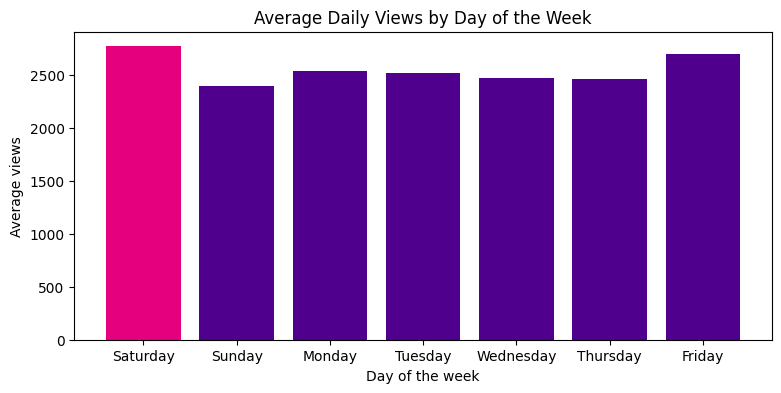

In [9]:
colors = ["#E5007D" if day == peak_day else "#4F008C" for day in views_by_day.index]

plt.figure(figsize=(9, 4))
plt.bar(views_by_day.index, views_by_day.values, color=colors)
plt.title("Average Daily Views by Day of the Week")
plt.xlabel("Day of the week")
plt.ylabel("Average views")
plt.show()

## Step 4b: Line Chart of the 60-Day Forecast

The grey line is what actually happened, and the purple line is our prediction.

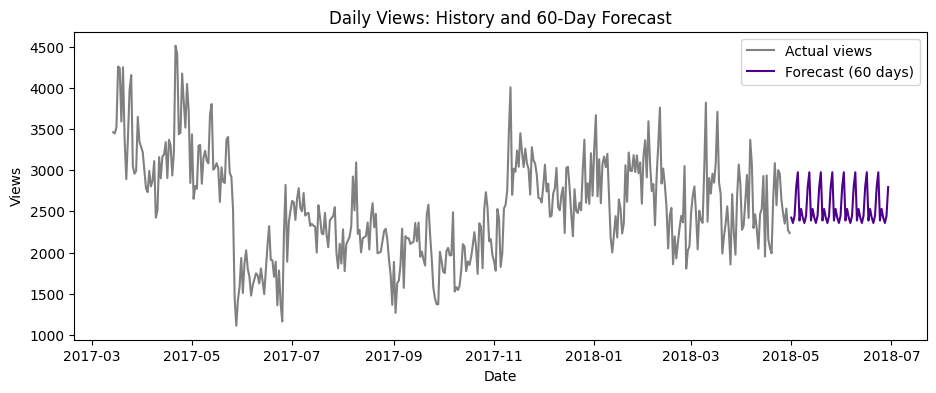

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(data["date_"], data["daily_views"], color="grey", label="Actual views")
plt.plot(forecast["date_"], forecast["predicted_views"], color="#4F008C", label="Forecast (60 days)")
plt.title("Daily Views: History and 60-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend()
plt.show()

## ✅ Summary and Recommendations / الملخص والتوصيات

### English

**Peak viewing days.** **Saturday** is the busiest day (about **2,770** views on average),
followed closely by **Friday** (about **2,696**). This makes sense because Friday and Saturday
were the weekend in Saudi Arabia during this period. **Sunday** is the quietest day (about **2,396**).

**60-day forecast (1 May – 29 June 2018).**

| Period | Expected views |
|---|---|
| Month 1 | ~76,451 |
| Month 2 | ~76,909 |
| **60-day total** | **~153,360** |

**Recommendations for stc tv**

1. **Content scheduling** — release new episodes and big titles on **Thursday evening**,
   so they are ready for the Friday–Saturday peak.
2. **Server capacity** — plan capacity for the Saturday peak, which runs about
   **16% above** the quietest day. Sunday and Wednesday are the safest days for maintenance.
3. **Marketing campaigns** — run campaigns Wednesday and Thursday, so users see them
   just before the weekend when they actually have time to watch.
4. **Watch the trend** — viewing is slowly declining, so the forecast is flat rather than growing.
   Treat ~153,000 views as the *baseline* the platform reaches without new action.

### عربي

**أيام الذروة.** **السبت** هو أعلى يوم مشاهدة (حوالي **٢٬٧٧٠** مشاهدة في المتوسط)،
يليه **الجمعة** (حوالي **٢٬٦٩٦**)، وهذا منطقي لأن الجمعة والسبت كانا عطلة نهاية الأسبوع
في السعودية في تلك الفترة. وأقل يوم هو **الأحد** (حوالي **٢٬٣٩٦**).

**توقّع الستين يومًا (١ مايو – ٢٩ يونيو ٢٠١٨):** الشهر الأول ~٧٦٬٤٥١ مشاهدة،
الشهر الثاني ~٧٦٬٩٠٩ مشاهدة، والإجمالي **~١٥٣٬٣٦٠ مشاهدة**.

**التوصيات**

1. **جدولة المحتوى** — إطلاق الحلقات والأعمال الجديدة **مساء الخميس** استعدادًا لذروة الجمعة والسبت.
2. **سعة الخوادم** — تجهيز السعة ليوم السبت الذي يزيد بنحو **١٦٪** عن أقل يوم،
   وجدولة الصيانة يومي الأحد والأربعاء.
3. **الحملات التسويقية** — تشغيل الحملات الأربعاء والخميس قبل بداية عطلة نهاية الأسبوع مباشرة.
4. **متابعة الاتجاه العام** — المشاهدات في انخفاض تدريجي، لذلك يُعدّ الرقم ١٥٣٬٠٠٠
   خط الأساس المتوقع دون أي إجراءات جديدة.

